<h1><center>IMT2118 - Ciencia de Datos Geoespaciales (2024-1) </center></h1>
<h2><center>Proyecto: Metro de Santiago</center></h2>

## LECTURA Y PREPROCESAMIENTO

In [17]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import geemap, ee
from shapely.geometry import Point
from shapely.ops import transform, nearest_points
from sklearn.cluster import DBSCAN
from libpysal.weights import Queen
from esda.moran import Moran_Local
import pyproj
from tqdm import tqdm
import matplotlib.patches as mpatches


from warnings import filterwarnings
filterwarnings("ignore")

# Autenticación e inicialización Earth Engine
ee.Authenticate()
ee.Initialize()

# Limites de Santiago Urbano
stgo = gpd.read_file("Datos/santiago_urbano.gpkg")
roi_shapely = stgo.union_all()

# Limite comunal (intersectado con Santiago Urbano)
Limite_Comunal = gpd.read_file("Datos/Limite_Comunal.gpkg")
Limite_Comunal['geometry'] = Limite_Comunal.geometry.intersection(roi_shapely)
Limite_Comunal = Limite_Comunal[~Limite_Comunal.is_empty]

# Zonas censales
zonas = gpd.read_file("Datos/datosZonas_Stgo_C2017.gpkg").to_crs(Limite_Comunal.crs)
zonas['centroide'] = zonas.geometry.centroid
zonas_centros = zonas.set_geometry('centroide')
zonas_centros = zonas_centros.sjoin(Limite_Comunal[['comuna', 'geometry']], how='left', predicate='within')
zonas['comuna'] = zonas_centros['comuna'].values


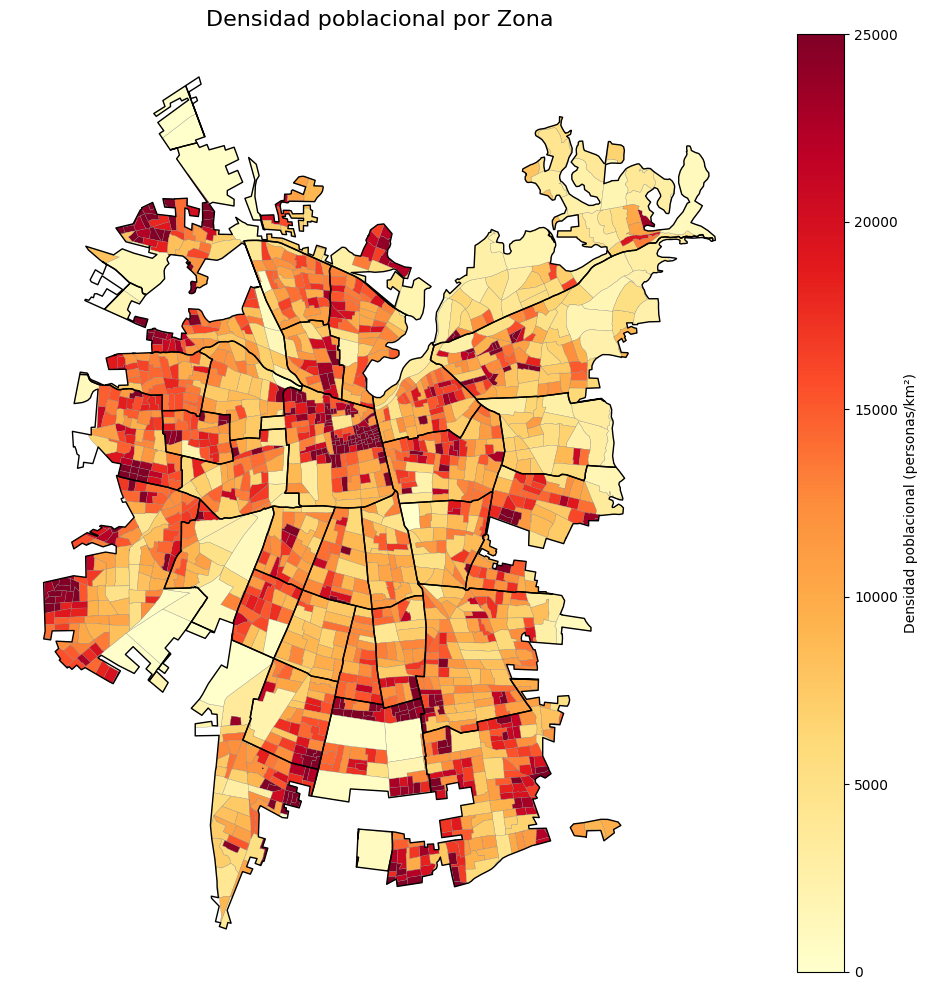

In [18]:
# Calcular área y densidad poblacional
zonas_proj = zonas.to_crs(epsg=32719)
zonas['area_km2'] = zonas_proj.geometry.area / 1e6
zonas['densidad'] = zonas['PERSONAS'] / zonas['area_km2']

# Visualización: densidad poblacional
fig, ax = plt.subplots(figsize=(10, 10))
vmax = 25000
zonas.plot(
    column='densidad', ax=ax, cmap='YlOrRd', legend=True, 
    legend_kwds={'label': "Densidad poblacional (personas/km²)"},
    edgecolor='gray', linewidth=0.2, vmax=vmax)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title('Densidad poblacional por Zona', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

## Red de Metro Actual y Covertura

In [19]:
# Plot Red de Metro
df = pd.read_csv("Datos/estaciones_metro.csv", decimal=',')
df['stop_lat'] = df['stop_lat'].astype(str).str.replace(',', '.').astype(float)
df['stop_lon'] = df['stop_lon'].astype(str).str.replace(',', '.').astype(float)
df['geometry'] = df.apply(lambda row: Point(row['stop_lon'], row['stop_lat']), axis=1)
gdf_estaciones = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# Leer líneas del metro y visualización en geemap
lineas_metro = gpd.read_file("Datos/lineas_metro.gpkg", layer="lineas")

m = geemap.Map(center=[-33.45, -70.65], zoom=5)
# Agregar Santiago urbano
m.add_gdf(stgo, layer_name="Santiago Urbano", style={"color": "black", "weight": 2, "fillOpacity": 0.05})

# Agregar límite comunal
m.add_gdf(Limite_Comunal, layer_name="Límite Comunal", style={"color": "gray", "weight": 1, "fillOpacity": 0.2})

for _, row in lineas_metro.iterrows():
    m.add_gdf(
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326"),
        layer_name=f"Línea {row['linea']}",
        style={"color": row["color"], "weight": 4}
    )
m

Map(center=[-33.45, -70.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…

## Cobertura Actual Metro

In [20]:
# Crear buffer de 1 km alrededor de estaciones
estaciones_proj = gdf_estaciones.to_crs(epsg=32719)
buffer_1km = estaciones_proj.buffer(1000)
buffer_union = buffer_1km.unary_union

# Volver a WGS84 para intersectar
project_back = pyproj.Transformer.from_crs(32719, 4326, always_xy=True).transform
buffer_1km_wgs = gpd.GeoSeries([transform(project_back, buffer_union)], crs="EPSG:4326")

# Determinar cobertura
zonas['cerca_metro'] = zonas.geometry.intersects(buffer_1km_wgs.iloc[0]).astype(int)

cubiertas = zonas[zonas['cerca_metro'] == 1]
no_cubiertas = zonas[zonas['cerca_metro'] == 0]
# Análisis espacial con clusters de Moran Local
w_zonas = Queen.from_dataframe(zonas)
moran_local = Moran_Local(zonas['cerca_metro'], w_zonas)

zonas['cluster_metro'] = 'No significativo'
zonas.loc[(moran_local.q == 1) & (moran_local.p_sim < 0.05), 'cluster_metro'] = 'Alto-Alto'
zonas.loc[(moran_local.q == 2) & (moran_local.p_sim < 0.05), 'cluster_metro'] = 'Bajo-Alto'
zonas.loc[(moran_local.q == 3) & (moran_local.p_sim < 0.05), 'cluster_metro'] = 'Bajo-Bajo'
zonas.loc[(moran_local.q == 4) & (moran_local.p_sim < 0.05), 'cluster_metro'] = 'Alto-Bajo'


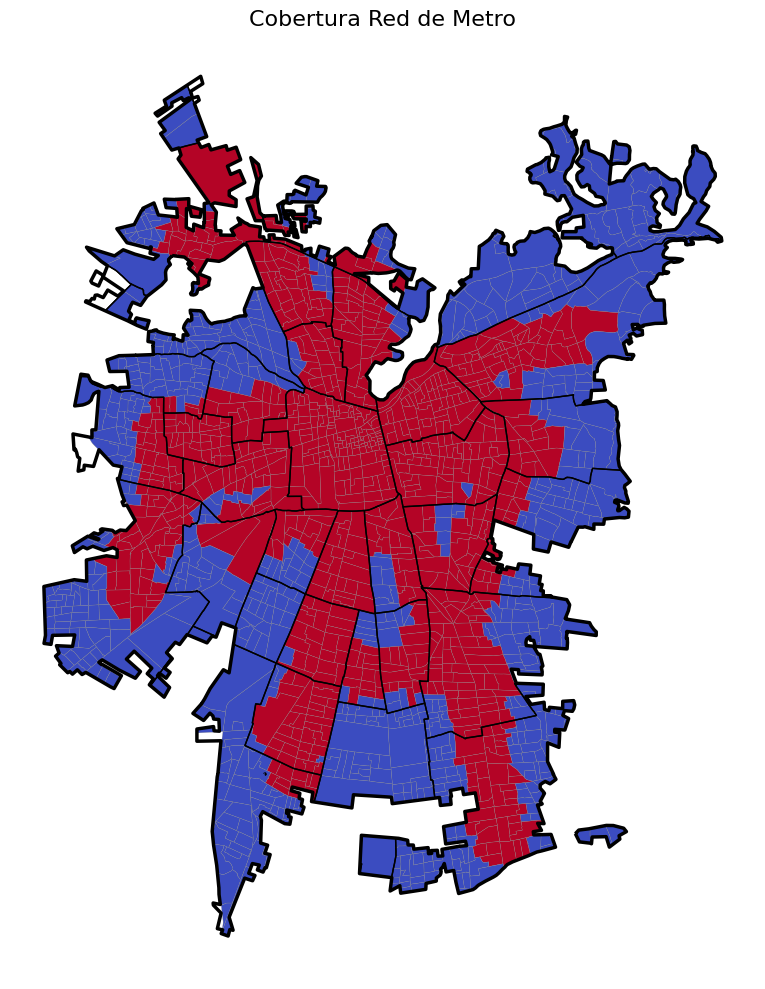

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(
    column='cerca_metro',
    cmap='coolwarm',
    legend=False,  # Quita la barra de color
    ax=ax,
    edgecolor='gray',
    linewidth=0.2
)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
stgo.boundary.plot(ax=ax, color='black', linewidth=2.5)
ax.set_title('Cobertura Red de Metro', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

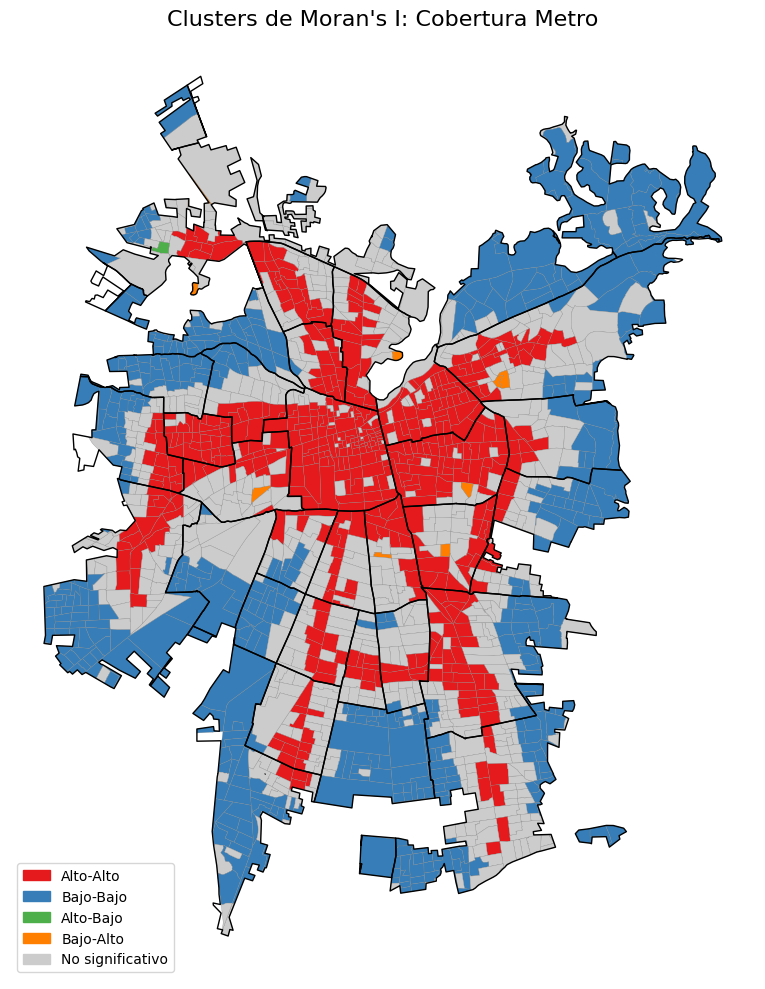

In [22]:
cluster_colors = {
    'Alto-Alto': '#e41a1c',
    'Bajo-Bajo': '#377eb8',
    'Alto-Bajo': '#4daf4a',
    'Bajo-Alto': '#ff7f00',
    'No significativo': '#cccccc'
}

fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, color=zonas['cluster_metro'].map(cluster_colors), edgecolor='gray', linewidth=0.2)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Clusters de Moran's I: Cobertura Metro", fontsize=16)
ax.axis('off')

legend_patches = [mpatches.Patch(color=color, label=label) for label, color in cluster_colors.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

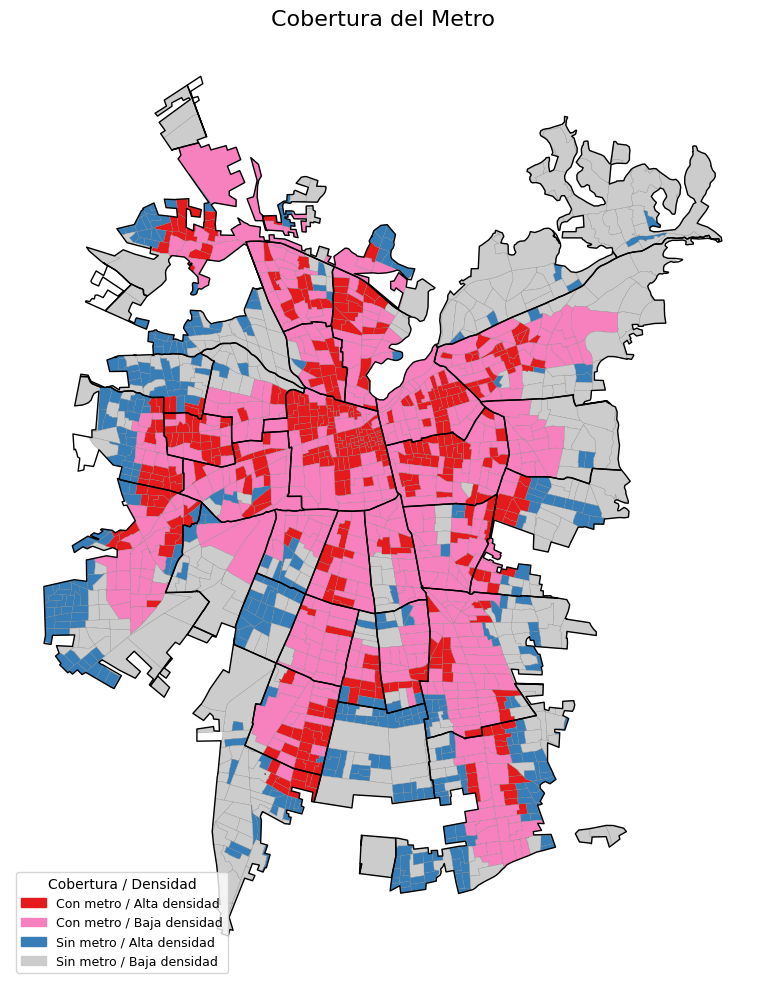

In [23]:
# Clasificación según cuartiles de densidad
zonas['dens_q'] = pd.qcut(zonas['densidad'], 2, labels=['Baja densidad', 'Alta densidad'])
zonas['metro_q'] = zonas['cerca_metro'].map({0: 'Sin metro', 1: 'Con metro'})
zonas['combo'] = zonas['metro_q'].astype(str) + " / " + zonas['dens_q'].astype(str)

# Visualización de zonas críticas combinadas
palette_combo = {
    'Con metro / Alta densidad': '#e41a1c',
    'Con metro / Baja densidad': '#f781bf',
    'Sin metro / Alta densidad': '#377eb8',
    'Sin metro / Baja densidad': '#cccccc'
}

fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, color=zonas['combo'].map(palette_combo), edgecolor='gray', linewidth=0.2)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Cobertura del Metro", fontsize=16)
ax.axis('off')

legend_patches = [mpatches.Patch(color=color, label=label) for label, color in palette_combo.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9, title='Cobertura / Densidad')

plt.tight_layout()
plt.show()

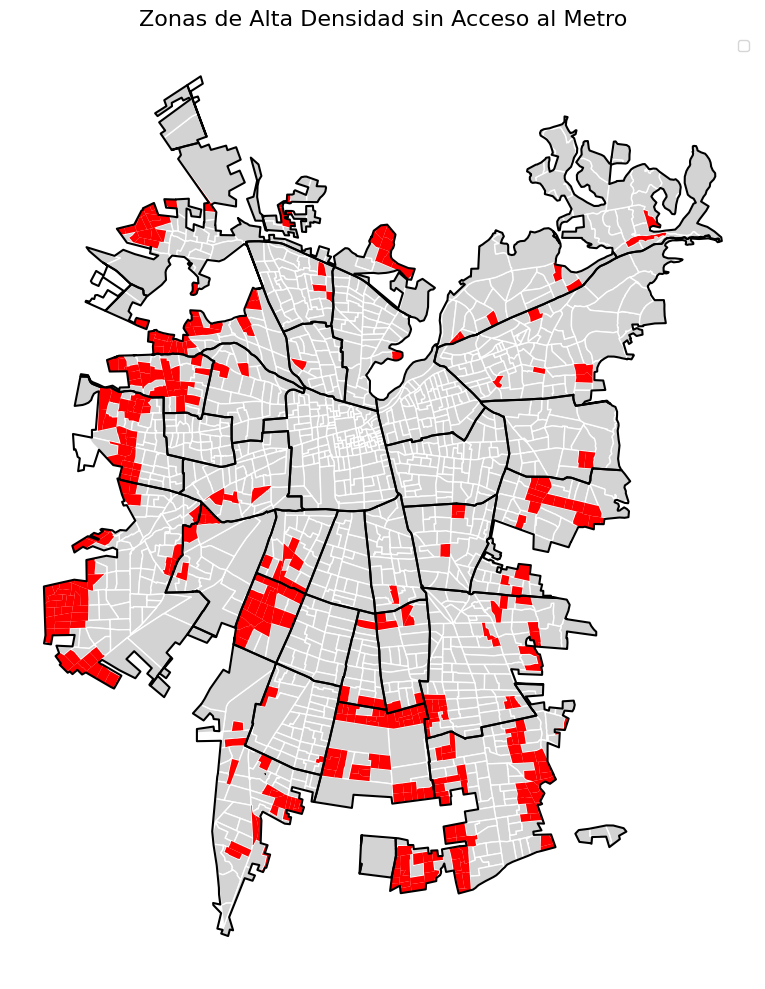

In [24]:
# Identificar zonas críticas (alta densidad sin metro)
zonas['centroide'] = zonas.geometry.centroid
zonas_criticas = zonas[(zonas['dens_q'] == 'Alta densidad') & (zonas['cerca_metro'] == 0)]

# Visualización de zonas críticas
fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='white')
zonas_criticas.plot(ax=ax, color='red', markersize=30, label='Alta densidad sin cobertura')
Limite_Comunal.boundary.plot(ax=ax, color='black')

ax.set_title("Zonas de Alta Densidad sin Acceso al Metro", fontsize=16)
ax.legend()
ax.axis('off')
plt.tight_layout()
plt.show()

In [25]:

# Población afectada en zonas críticas
total_personas_zonas_criticas = zonas_criticas['PERSONAS'].sum()
print(f"Ppersonas en zonas de alta densidad sin metro cercano: {total_personas_zonas_criticas:,}")
personas_sin_metro = zonas.loc[zonas['cerca_metro'] == 0, 'PERSONAS'].sum()
print(f"Personas sin acceso cercano al metro: {personas_sin_metro:,}")

Ppersonas en zonas de alta densidad sin metro cercano: 1,520,095
Personas sin acceso cercano al metro: 2,665,195


In [26]:
Metro = gdf_estaciones.copy()
# Cruce espacial para asignar comuna a cada estación
gdf_estaciones_comunas = gpd.sjoin(gdf_estaciones, Limite_Comunal, how='left', predicate='within')

# Conteo de estaciones por comuna
conteo = gdf_estaciones_comunas['comuna'].value_counts().sort_index()

# Comunas que no tienen ninguna estación
comunas_todas = Limite_Comunal['comuna'].unique()
comunas_sin_metro = set(comunas_todas) - set(conteo.index)

print("Comunas sin estaciones de metro:")
print(sorted(comunas_sin_metro))

personas_por_comuna = zonas.groupby('comuna')['PERSONAS'].sum()
# Filtrar las comunas sin metro en personas_por_comuna
personas_sin_metro = personas_por_comuna[personas_por_comuna.index.isin(comunas_sin_metro)]
print("")

print(f"Total de personas en comunas sin metro: {personas_sin_metro.sum()}")

Comunas sin estaciones de metro:
['CERRO NAVIA', 'COLINA', 'HUECHURABA', 'LA PINTANA', 'LAMPA', 'LO BARNECHEA', 'LO ESPEJO', 'RENCA', 'VITACURA']

Total de personas en comunas sin metro: 777211


In [27]:
# Para todas las zonas
zonas_proj = zonas.to_crs(epsg=32719)
gdf_estaciones_proj = gdf_estaciones.to_crs(epsg=32719)
centroides_todas = zonas_proj.geometry.centroid
estaciones_points = gdf_estaciones_proj.geometry.unary_union
zonas_proj['dist_estacion_km'] = centroides_todas.apply(lambda x: x.distance(nearest_points(x, estaciones_points)[1]) / 1000)
dist_promedio_todas = zonas_proj['dist_estacion_km'].mean()
print(f"Distancia promedio a la estación de metro más cercana para TODAS las zonas: {dist_promedio_todas:.2f} km")

# Para zonas no cubiertas
no_cubiertas_proj = no_cubiertas.to_crs(epsg=32719)
centroides_no_cubiertas = no_cubiertas_proj.geometry.centroid
no_cubiertas_proj['dist_estacion_km'] = centroides_no_cubiertas.apply(lambda x: x.distance(nearest_points(x, estaciones_points)[1]) / 1000)
dist_promedio_no_cubiertas = no_cubiertas_proj['dist_estacion_km'].mean()
print(f"Distancia promedio a la estación de metro más cercana para ZONAS NO CUBIERTAS: {dist_promedio_no_cubiertas:.2f} km")
# 19 y 32 minutos, 5 km/h


Distancia promedio a la estación de metro más cercana para TODAS las zonas: 1.58 km
Distancia promedio a la estación de metro más cercana para ZONAS NO CUBIERTAS: 2.70 km


## Nuevas Lineas

In [28]:
# Leer y Mapa Nuevas Lineas
lineas_metro = gpd.read_file("Datos/nuevas_lineas_metro.gpkg", layer="lineas")

df_nuevas = pd.read_csv("Datos/nuevas_estaciones.csv")
# Crear mapa centrado en Santiago
m = geemap.Map(center=[-33.45, -70.65], zoom=8)

m.add_gdf(stgo, layer_name="Santiago Urbano", style={"color": "black", "weight": 2, "fillOpacity": 0.05})

# Agregar límite comunal
m.add_gdf(Limite_Comunal, layer_name="Límite Comunal", style={"color": "gray", "weight": 1, "fillOpacity": 0.2})

# Agregar cada línea al mapa con su color y estilo
for _, row in lineas_metro.iterrows():
    m.add_gdf(
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326"),
        layer_name=f"Línea {row['linea']}",
        style={"color": row["color"], "weight": 4}
    )

m

Map(center=[-33.45, -70.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…

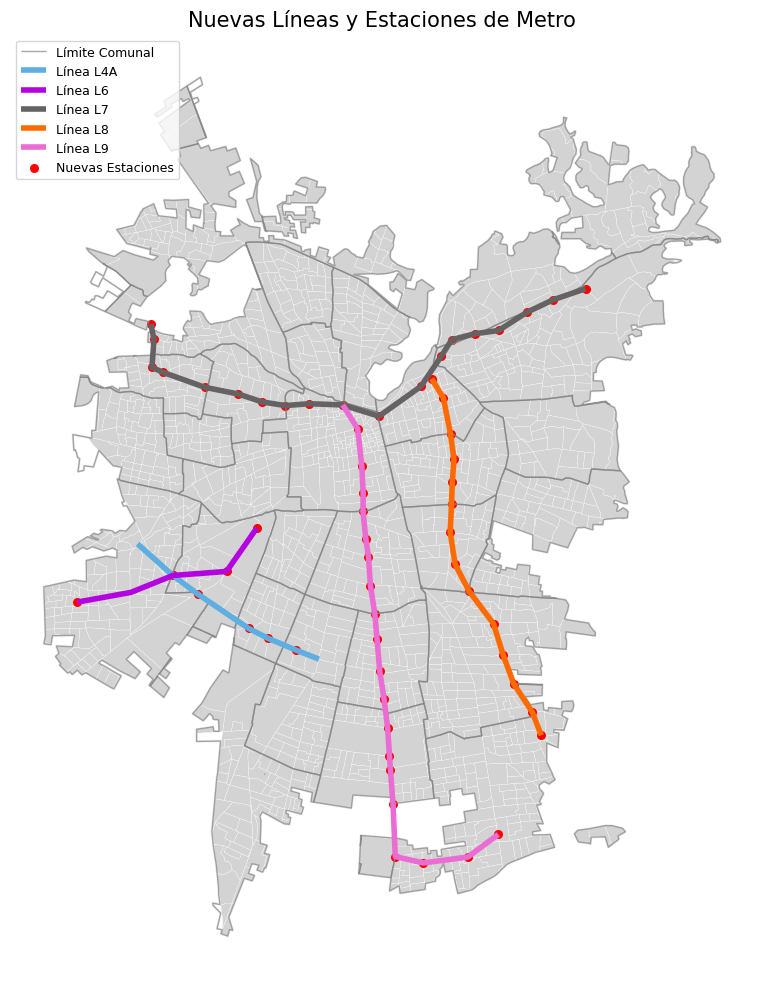

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))

# Fondo: Santiago urbano
stgo.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, alpha=0.05, label="Santiago Urbano")

# Límite comunal
Limite_Comunal.boundary.plot(ax=ax, color='gray', linewidth=1, alpha=0.7, label="Límite Comunal")

# Zonas (relleno claro)
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='white', linewidth=0.2, label="Zonas censales")

# Nuevas líneas de metro
for _, row in lineas_metro.iterrows():
    gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326").plot(
        ax=ax, color=row["color"], linewidth=4, label=f"Línea {row['linea']}"
    )

# Nuevas estaciones (si hay columnas de lat/lon)
if 'stop_lat' in df_nuevas.columns and 'stop_lon' in df_nuevas.columns:
    ax.scatter(df_nuevas['stop_lon'], df_nuevas['stop_lat'], color='red', s=30, label='Nuevas Estaciones')

ax.set_title("Nuevas Líneas y Estaciones de Metro", fontsize=15)
ax.axis('off')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [30]:
# Zonas con Nuevas coberturas
gdf_actuales = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
# Ensure geometry column in df_nuevas is valid shapely Point objects
if not isinstance(df_nuevas.geometry.iloc[0], Point):
	df_nuevas['geometry'] = df_nuevas.apply(lambda row: Point(row['stop_lon'], row['stop_lat']), axis=1)
gdf_nuevas = gpd.GeoDataFrame(df_nuevas, geometry='geometry', crs="EPSG:4326")

gdf_total = pd.concat([gdf_actuales, gdf_nuevas], ignore_index=True)

df_completo = pd.concat([df, df_nuevas], ignore_index=True)


buffer_act_proj = gdf_actuales.to_crs(epsg=32719).buffer(1000).unary_union
buffer_nvo_proj = gdf_total.to_crs(epsg=32719).buffer(1000).unary_union

# Volver a WGS84
to_wgs84 = pyproj.Transformer.from_crs(32719, 4326, always_xy=True).transform
buffer_act_wgs = gpd.GeoSeries([transform(to_wgs84, buffer_act_proj)], crs="EPSG:4326")
buffer_nvo_wgs = gpd.GeoSeries([transform(to_wgs84, buffer_nvo_proj)], crs="EPSG:4326")

# Evaluar cobertura de zonas
zonas['cerca_metro'] = zonas.geometry.intersects(buffer_act_wgs.iloc[0]).astype(int)
zonas['cerca_metro_nuevo'] = zonas.geometry.intersects(buffer_nvo_wgs.iloc[0]).astype(int)

# ¿Qué zonas ganan cobertura?
zonas['gana_cobertura'] = ((zonas['cerca_metro'] == 0) & (zonas['cerca_metro_nuevo'] == 1)).astype(int)
zonas_ganan = zonas[zonas['gana_cobertura'] == 1]

# Personas beneficiadas
personas_ganan = zonas_ganan['PERSONAS'].sum()

# Filtrar zonas de alta densidad
zonas['dens_q'] = pd.qcut(zonas['densidad'], 2, labels=['Baja densidad', 'Alta densidad'])
zonas_ganan_alta = zonas_ganan[zonas_ganan['dens_q'] == 'Alta densidad']

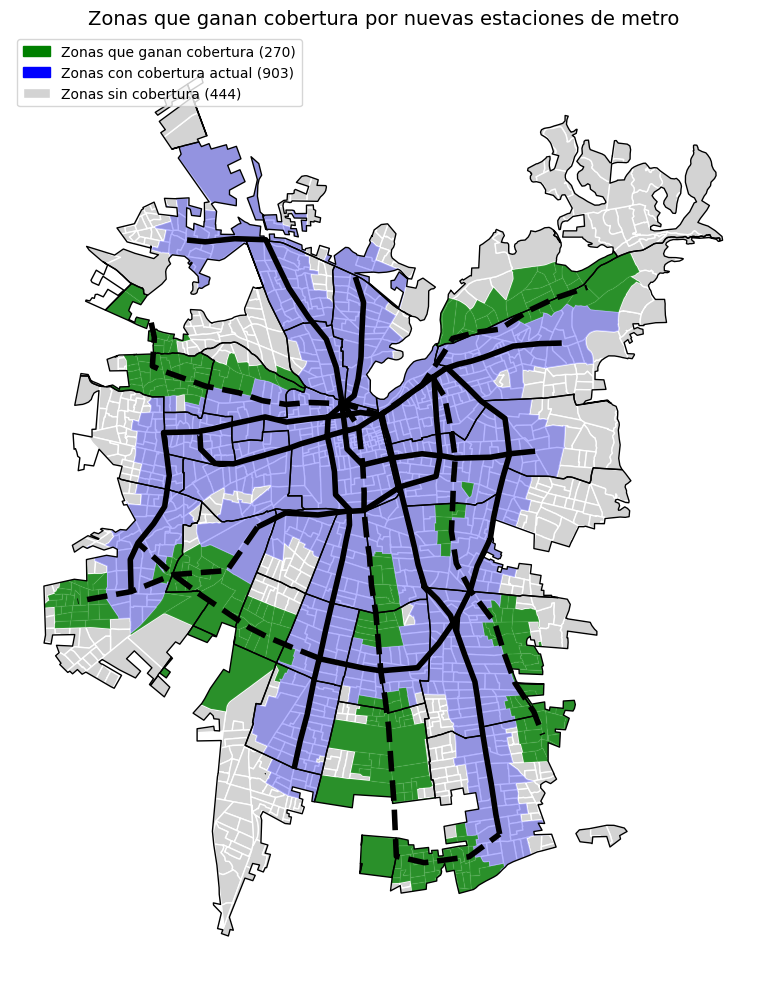

Personas beneficiadas: 971,599
Personas en zonas de alta densidad que ganan cobertura: 542,151


In [31]:
# Definir zonas_previas como aquellas que ya tenían cobertura antes de las nuevas estaciones
zonas_previas = zonas[zonas['cerca_metro'] == 1]

fig, ax = plt.subplots(figsize=(10, 10))

# Fondo gris claro
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='white')

# Zonas que ganan cobertura (alta precisión)
zonas_ganan.plot(ax=ax, color='green', label='Zonas que ganan cobertura', alpha=0.8)

# Zonas que ya tenían cobertura
zonas_previas.plot(ax=ax, color='blue', label='Zonas con cobertura actual', alpha=0.3)

# Agregar líneas de metro actuales
lineas_actuales = gpd.read_file("Datos/lineas_metro.gpkg", layer="lineas")
for _, row in lineas_actuales.iterrows():
    row_gdf = gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326")
    row_gdf.plot(ax=ax, color="black", linewidth=4, label=f"Línea {row['linea']}")

# Agregar líneas de metro nuevas
lineas_nuevas = gpd.read_file("Datos/nuevas_lineas_metro.gpkg", layer="lineas")
for _, row in lineas_nuevas.iterrows():
    row_gdf = gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326")
    row_gdf.plot(ax=ax, color="black", linewidth=4, linestyle="--", label=f"Nueva línea {row['linea']}")

Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)

ax.set_title("Zonas que ganan cobertura por nuevas estaciones de metro", fontsize=14)
ax.axis('off')

# Cantidades
n_ganan = len(zonas_ganan)
n_previas = len(zonas_previas)
n_sin = len(zonas) - n_ganan - n_previas

# Agregar leyenda personalizada con cantidades
legend_patches = [
    mpatches.Patch(color='green', label=f'Zonas que ganan cobertura ({n_ganan})'),
    mpatches.Patch(color='blue', label=f'Zonas con cobertura actual ({n_previas})'),
    mpatches.Patch(facecolor='lightgray', edgecolor='white', label=f'Zonas sin cobertura ({n_sin})')
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Personas beneficiadas: {personas_ganan:,}")
print(f"Personas en zonas de alta densidad que ganan cobertura: {zonas_ganan_alta['PERSONAS'].sum():,}")

In [32]:
# Para todas las zonas con la nueva red de metro
zonas_proj = zonas.to_crs(epsg=32719)
# Usar todas las estaciones (actuales + nuevas)
gdf_total_proj = gdf_total.to_crs(epsg=32719)
estaciones_points_nuevas = gdf_total_proj.geometry.unary_union

centroides_todas = zonas_proj.geometry.centroid
zonas_proj['dist_estacion_km_nueva'] = centroides_todas.apply(
    lambda x: x.distance(nearest_points(x, estaciones_points_nuevas)[1]) / 1000
)
dist_promedio_todas_nueva = zonas_proj['dist_estacion_km_nueva'].mean()
print(f"Distancia promedio a la estación de metro más cercana para TODAS las zonas (nueva red): {dist_promedio_todas_nueva:.2f} km")

# Para zonas no cubiertas por la nueva red
no_cubiertas_nueva = zonas[zonas['cerca_metro_nuevo'] == 0]
no_cubiertas_nueva_proj = no_cubiertas_nueva.to_crs(epsg=32719)
centroides_no_cubiertas_nueva = no_cubiertas_nueva_proj.geometry.centroid
no_cubiertas_nueva_proj['dist_estacion_km_nueva'] = centroides_no_cubiertas_nueva.apply(
    lambda x: x.distance(nearest_points(x, estaciones_points_nuevas)[1]) / 1000
)
dist_promedio_no_cubiertas_nueva = no_cubiertas_nueva_proj['dist_estacion_km_nueva'].mean()
print(f"Distancia promedio a la estación de metro más cercana para ZONAS NO CUBIERTAS (nueva red): {dist_promedio_no_cubiertas_nueva:.2f} km")

Distancia promedio a la estación de metro más cercana para TODAS las zonas (nueva red): 1.13 km
Distancia promedio a la estación de metro más cercana para ZONAS NO CUBIERTAS (nueva red): 2.30 km


## MetroTren

In [33]:
# Leer estaciones de Metrotren
df_metrotren = pd.read_csv("Datos/estaciones_metrotren.csv", decimal=',')

# Asumimos que las columnas correctas son 'lat' y 'lon', ajústalas si son diferentes
lat_col = None
lon_col = None
for c in df_metrotren.columns:
    if 'lat' in c.lower():
        lat_col = c
    if 'lon' in c.lower():
        lon_col = c

if lat_col is None or lon_col is None:
    raise ValueError("No se encontraron columnas de latitud/longitud en el archivo CSV.")

# Asegurar coordenadas tipo float
for col in [lat_col, lon_col]:
    df_metrotren[col] = df_metrotren[col].astype(str).str.replace(',', '.').astype(float)

df_metrotren['geometry'] = df_metrotren.apply(lambda row: Point(row[lon_col], row[lat_col]), axis=1)
gdf_metrotren = gpd.GeoDataFrame(df_metrotren, geometry='geometry', crs="EPSG:4326")

# Unir estaciones de metro y metrotren
gdf_total_metrotren = pd.concat([gdf_total, gdf_metrotren], ignore_index=True)
gdf_total_metrotren = gdf_total_metrotren.drop_duplicates(subset=['geometry'])

# Proyección métrica y buffer 1km
gdf_total_metrotren_proj = gdf_total_metrotren.to_crs(epsg=32719)
buffer_1km_total_metrotren = gdf_total_metrotren_proj.buffer(1000)
buffer_union_total_metrotren = buffer_1km_total_metrotren.unary_union

# Volver a WGS84
project_back = pyproj.Transformer.from_crs(32719, 4326, always_xy=True).transform
buffer_1km_total_metrotren_wgs = gpd.GeoSeries([transform(project_back, buffer_union_total_metrotren)], crs="EPSG:4326")

# Revisar ocupación del buffer (zonas cubiertas por metro o metrotren)
zonas['cerca_metro_metrotren'] = zonas.geometry.intersects(buffer_1km_total_metrotren_wgs.iloc[0]).astype(int)
zonas['gana_cobertura_metrotren'] = ((zonas['cerca_metro'] == 0) & (zonas['cerca_metro_metrotren'] == 1)).astype(int)

# Personas beneficiadas por estaciones de metrotren (adicionales)
personas_beneficiadas_metrotren = zonas.loc[zonas['gana_cobertura_metrotren'] == 1, 'PERSONAS'].sum()
print(f"Personas beneficiadas por estaciones de metrotren: {personas_beneficiadas_metrotren:,}")

Personas beneficiadas por estaciones de metrotren: 1,217,642


In [34]:
# Asignar comuna a cada estación de metrotren
gdf_metrotren_sjoin = gpd.sjoin(gdf_metrotren, Limite_Comunal, how='left', predicate='within')

# Asignar comuna a cada estación de metro (actuales + nuevas)
gdf_total_sjoin = gpd.sjoin(gdf_total, Limite_Comunal, how='left', predicate='within')

# Conjuntos de comunas
comunas_metrotren = set(gdf_metrotren_sjoin['comuna'].dropna())
comunas_total_metro = set(gdf_total_sjoin['comuna'].dropna())
comunas_total_metrotren = comunas_total_metro.union(comunas_metrotren)

# Comunas que ganan con Metrotren
comunas_sin_metrotren = set(comunas_todas) - comunas_total_metrotren
comunas_que_ganan_metrotren = set(comunas_sin_metro) - comunas_sin_metrotren

# Población por comuna
personas_sin_metrotren = personas_por_comuna[personas_por_comuna.index.isin(comunas_sin_metrotren)].sum()
personas_ganan_comuna_metrotren = personas_por_comuna[personas_por_comuna.index.isin(comunas_que_ganan_metrotren)].sum()

# Alta densidad y cobertura Metrotren
zonas_ganan_metrotren = zonas[(zonas['gana_cobertura_metrotren'] == 1)]
zonas_ganan_metrotren_alta = zonas_ganan_metrotren[zonas_ganan_metrotren['dens_q'] == 'Alta densidad']
personas_ganan_zonas_metrotren = zonas_ganan_metrotren['PERSONAS'].sum()
personas_ganan_zonas_metrotren_alta = zonas_ganan_metrotren_alta['PERSONAS'].sum()

# Imprimir resultados
print("\nComunas sin estaciones (Metro + Metrotren):", sorted(comunas_sin_metrotren))
print("Comunas que ganan cobertura con Metrotren:", sorted(comunas_que_ganan_metrotren))
print(f"\nTotal personas en comunas sin cobertura (Metro + Metrotren): {personas_sin_metrotren:,}")
print(f"Personas beneficiadas por Metrotren (por comuna): {personas_ganan_comuna_metrotren:,}")
print(f"Zonas que ganan cobertura con Metrotren: {len(zonas_ganan_metrotren)}")
print(f"Zonas de alta densidad que ganan cobertura con Metrotren: {len(zonas_ganan_metrotren_alta)}")
print(f"Personas en zonas beneficiadas por Metrotren: {personas_ganan_zonas_metrotren:,}")
print(f"Personas en zonas críticas (alta densidad) beneficiadas por Metrotren: {personas_ganan_zonas_metrotren_alta:,}")



Comunas sin estaciones (Metro + Metrotren): ['COLINA', 'HUECHURABA', 'LAMPA', 'LO BARNECHEA']
Comunas que ganan cobertura con Metrotren: ['CERRO NAVIA', 'LA PINTANA', 'LO ESPEJO', 'RENCA', 'VITACURA']

Total personas en comunas sin cobertura (Metro + Metrotren): 164,238
Personas beneficiadas por Metrotren (por comuna): 612,973
Zonas que ganan cobertura con Metrotren: 335
Zonas de alta densidad que ganan cobertura con Metrotren: 160
Personas en zonas beneficiadas por Metrotren: 1,217,642
Personas en zonas críticas (alta densidad) beneficiadas por Metrotren: 648,240


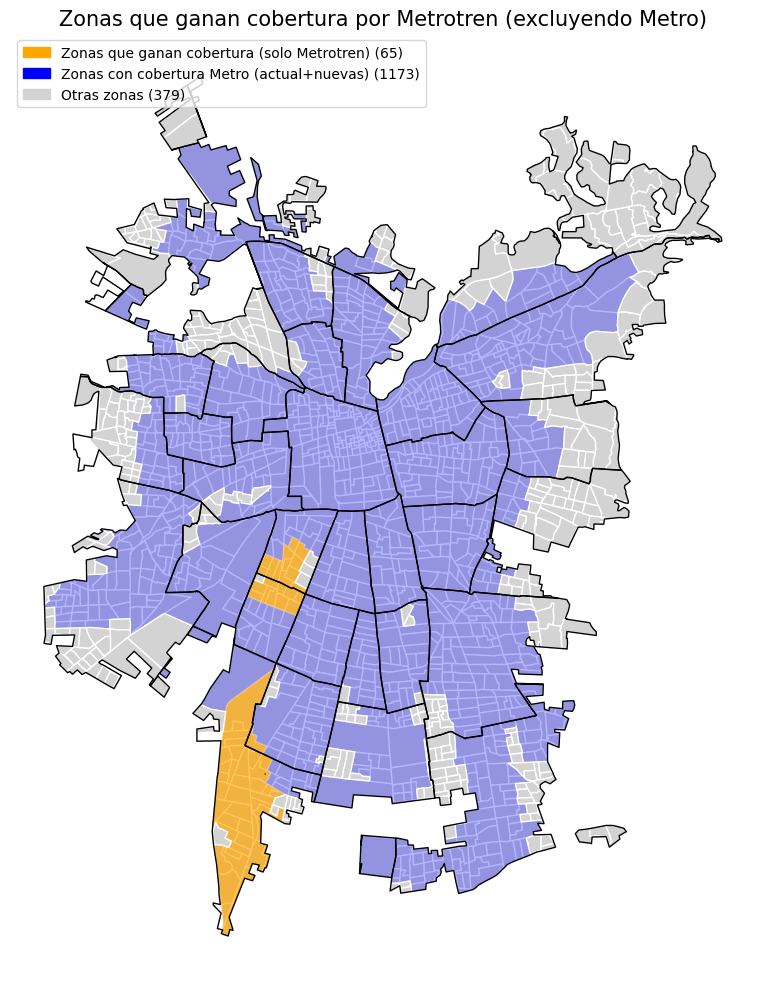

Personas beneficiadas solo por Metrotren: 246,043
Personas en zonas de alta densidad que ganan cobertura solo con Metrotren: 106,089
Distancia promedio a la estación de metro o metrotren más cercana para TODAS las zonas: 1.04 km
Distancia promedio a la estación de metro o metrotren más cercana para ZONAS NO CUBIERTAS: 2.19 km
Distancia promedio a la estación de metro o metrotren más cercana para ZONAS DE ALTA DENSIDAD NO CUBIERTAS: 1.91 km


In [35]:
# Definir zonas que ganan cobertura solo por Metrotren (no cubiertas por Metro nuevo, pero sí por Metrotren)
zonas_ganan_solo_metrotren = zonas[(zonas['cerca_metro_nuevo'] == 0) & (zonas['gana_cobertura_metrotren'] == 1)]
personas_beneficiadas_solo_metrotren = zonas_ganan_solo_metrotren['PERSONAS'].sum()

# Visualización: Zonas que ganan cobertura solo por Metrotren (excluyendo las que ya ganaron con Metro)
n_ganan_metrotren = len(zonas_ganan_solo_metrotren)
n_cubiertas_metro = (zonas['cerca_metro_nuevo'] == 1).sum()
n_otras_metrotren = len(zonas) - n_ganan_metrotren - n_cubiertas_metro

fig, ax = plt.subplots(figsize=(10, 10))
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='white')
zonas[zonas['cerca_metro_nuevo'] == 1].plot(ax=ax, color='blue', alpha=0.3, label='Zonas con cobertura Metro (actual+nuevas)')
zonas_ganan_solo_metrotren.plot(ax=ax, color='orange', label='Zonas que ganan cobertura (solo Metrotren)', alpha=0.7)
zonas[(zonas['cerca_metro_nuevo'] == 0) & (zonas['gana_cobertura_metrotren'] == 0)].plot(ax=ax, facecolor='lightgray', edgecolor='white')
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)

ax.set_title("Zonas que ganan cobertura por Metrotren (excluyendo Metro)", fontsize=15)
ax.axis('off')

legend_patches = [
    mpatches.Patch(color='orange', label=f'Zonas que ganan cobertura (solo Metrotren) ({n_ganan_metrotren})'),
    mpatches.Patch(color='blue', label=f'Zonas con cobertura Metro (actual+nuevas) ({n_cubiertas_metro})'),
    mpatches.Patch(color='lightgray', label=f'Otras zonas ({n_otras_metrotren})')
]
ax.legend(handles=legend_patches, loc='upper left')
plt.tight_layout()
plt.show()

# Personas beneficiadas solo por Metrotren
print(f"Personas beneficiadas solo por Metrotren: {personas_beneficiadas_solo_metrotren:,}")
zonas_ganan_solo_metrotren_alta = zonas_ganan_solo_metrotren[zonas_ganan_solo_metrotren['dens_q'] == 'Alta densidad']
print(f"Personas en zonas de alta densidad que ganan cobertura solo con Metrotren: {zonas_ganan_solo_metrotren_alta['PERSONAS'].sum():,}")


# Calcular distancia promedio a la estación más cercana (Metro + Metrotren)
gdf_total_metrotren_proj = gdf_total_metrotren.to_crs(epsg=32719)
estaciones_points_metrotren = gdf_total_metrotren_proj.geometry.unary_union

centroides_todas = zonas_proj.geometry.centroid
zonas_proj['dist_estacion_km_metrotren'] = centroides_todas.apply(
    lambda x: x.distance(nearest_points(x, estaciones_points_metrotren)[1]) / 1000
)
dist_promedio_todas_metrotren = zonas_proj['dist_estacion_km_metrotren'].mean()
print(f"Distancia promedio a la estación de metro o metrotren más cercana para TODAS las zonas: {dist_promedio_todas_metrotren:.2f} km")

# Para zonas no cubiertas por Metro ni Metrotren
no_cubiertas_metrotren = zonas[zonas['cerca_metro_metrotren'] == 0]
no_cubiertas_metrotren_proj = no_cubiertas_metrotren.to_crs(epsg=32719)
centroides_no_cubiertas_metrotren = no_cubiertas_metrotren_proj.geometry.centroid
no_cubiertas_metrotren_proj['dist_estacion_km_metrotren'] = centroides_no_cubiertas_metrotren.apply(
    lambda x: x.distance(nearest_points(x, estaciones_points_metrotren)[1]) / 1000
)
dist_promedio_no_cubiertas_metrotren = no_cubiertas_metrotren_proj['dist_estacion_km_metrotren'].mean()
print(f"Distancia promedio a la estación de metro o metrotren más cercana para ZONAS NO CUBIERTAS: {dist_promedio_no_cubiertas_metrotren:.2f} km")

# Para zonas de alta densidad no cubiertas por Metro ni Metrotren
no_cubiertas_metrotren_alta = no_cubiertas_metrotren[no_cubiertas_metrotren['dens_q'] == 'Alta densidad']
no_cubiertas_metrotren_alta_proj = no_cubiertas_metrotren_alta.to_crs(epsg=32719)
centroides_no_cubiertas_metrotren_alta = no_cubiertas_metrotren_alta_proj.geometry.centroid
no_cubiertas_metrotren_alta_proj['dist_estacion_km_metrotren'] = centroides_no_cubiertas_metrotren_alta.apply(
    lambda x: x.distance(nearest_points(x, estaciones_points_metrotren)[1]) / 1000
)
dist_promedio_no_cubiertas_metrotren_alta = no_cubiertas_metrotren_alta_proj['dist_estacion_km_metrotren'].mean()
print(f"Distancia promedio a la estación de metro o metrotren más cercana para ZONAS DE ALTA DENSIDAD NO CUBIERTAS: {dist_promedio_no_cubiertas_metrotren_alta:.2f} km")


In [52]:
# Asegurar que 'dens_q' existe en los dataframes filtrados
if 'dens_q' not in no_cubiertas.columns:
    no_cubiertas = zonas[zonas['cerca_metro'] == 0]
if 'dens_q' not in no_cubiertas_nueva.columns:
    no_cubiertas_nueva = zonas[zonas['cerca_metro_nuevo'] == 0]

# Diferencia de distancia promedio a estación más cercana (todas las zonas)
delta_dist_todas = dist_promedio_todas - dist_promedio_todas_nueva
delta_dist_todas_metrotren = dist_promedio_todas - dist_promedio_todas_metrotren

print(f"Diferencia promedio (todas las zonas):")
print(f"- Metro actual vs. Metro + Metrotren: {delta_dist_todas_metrotren:.2f} km")

# Diferencia de distancia promedio a estación más cercana (zonas no cubiertas)
delta_dist_no_cubiertas = dist_promedio_no_cubiertas - dist_promedio_no_cubiertas_nueva
delta_dist_no_cubiertas_metrotren = dist_promedio_no_cubiertas - dist_promedio_no_cubiertas_metrotren

print(f"\nDiferencia promedio (zonas no cubiertas):")
print(f"- Metro actual vs. Metro + Metrotren: {delta_dist_no_cubiertas_metrotren:.2f} km")

# Diferencia de distancia promedio a estación más cercana (zonas de alta densidad no cubiertas)
delta_dist_no_cubiertas_alta = (
    no_cubiertas[no_cubiertas['dens_q'] == 'Alta densidad']
    .to_crs(epsg=32719)
    .geometry.centroid
    .apply(lambda x: x.distance(nearest_points(x, estaciones_points)[1]) / 1000)
    .mean()
    - no_cubiertas_nueva[no_cubiertas_nueva['dens_q'] == 'Alta densidad']
    .to_crs(epsg=32719)
    .geometry.centroid
    .apply(lambda x: x.distance(nearest_points(x, estaciones_points_nuevas)[1]) / 1000)
    .mean()
)
delta_dist_no_cubiertas_alta_metrotren = (
    no_cubiertas[no_cubiertas['dens_q'] == 'Alta densidad']
    .to_crs(epsg=32719)
    .geometry.centroid
    .apply(lambda x: x.distance(nearest_points(x, estaciones_points)[1]) / 1000)
    .mean()
    - no_cubiertas_metrotren_alta_proj['dist_estacion_km_metrotren'].mean()
)

print(f"\nDiferencia promedio (zonas de alta densidad no cubiertas):")
print(f"- Metro actual vs. Metro + Metrotren: {delta_dist_no_cubiertas_alta_metrotren:.2f} km")

Diferencia promedio (todas las zonas):
- Metro actual vs. Metro + Metrotren: 0.54 km

Diferencia promedio (zonas no cubiertas):
- Metro actual vs. Metro + Metrotren: 0.51 km

Diferencia promedio (zonas de alta densidad no cubiertas):
- Metro actual vs. Metro + Metrotren: 0.60 km


## Img Satelitales

In [56]:
gran_santiago = ee.Geometry.Polygon([
    [[-71.05, -33.95], [-71.05, -33.15], [-70.25, -33.15], [-70.25, -33.95]]
])

def mask_s2_sr_clouds(image):
    cloud_prob = image.select('MSK_CLDPRB')
    cloud_mask = cloud_prob.lt(20)
    return image.updateMask(cloud_mask).copyProperties(image, ["system:time_start"])

def get_annual_composite(year):
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    collection = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(start_date, end_date)
        .filterBounds(gran_santiago)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2_sr_clouds)
    )
    count = collection.size().getInfo()
    if count == 0:
        print(f"No hay imágenes para el año {year}")
        return None
    return collection.median().clip(gran_santiago)

def ndvi(image):
    return image.normalizedDifference(['B8', 'B4']).rename('NDVI')

def ndbi(image):
    return image.normalizedDifference(['B11', 'B8']).rename('NDBI')

def get_ndvi_ndbi(year):
    img = get_annual_composite(year)
    if img:
        return img.addBands(ndvi(img)).addBands(ndbi(img))
    return None

img_2019 = get_ndvi_ndbi(2019)
img_2024 = get_ndvi_ndbi(2024)

ndvi_diff = img_2024.select('NDVI').subtract(img_2019.select('NDVI')).rename('NDVI_Diff')
ndbi_diff = img_2024.select('NDBI').subtract(img_2019.select('NDBI')).rename('NDBI_Diff')
diff_stack = ndvi_diff.addBands(ndbi_diff)

In [58]:
limite_comunal_ee = geemap.geopandas_to_ee(Limite_Comunal)

zonales_comunas = diff_stack.reduceRegions(
    collection=limite_comunal_ee,
    reducer=ee.Reducer.mean(),
    scale=30
)

Map = geemap.Map(center=[-33.45, -70.65], zoom=5)


vis_params = {
    'min': -0.5,
    'max': 0.5,
    'palette': [
        '006837', '1a9850', '66bd63', '000000', 'f46d43', 'd73027', 'a50026'
    ]
}

Map.addLayer(ndbi_diff, vis_params, 'Cambio NDBI 2019–2024')
Map.add_gdf(Limite_Comunal.boundary, layer_name='Límites comunales', style={'color': 'white', 'weight': 0.5, 'fillOpacity': 0})
Map.addLayerControl()

Map.add_gdf(stgo, layer_name="Santiago Urbano", style={"color": "white", "weight": 2, "fillOpacity": 0})

Map
Map.to_html("mapa_ndbi.html")


In [38]:
def get_viirs_annual_mean(year):
    collection = (
        ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .select('avg_rad')
        .filterBounds(gran_santiago)
    )
    return collection.mean().clip(gran_santiago)

viirs_2018 = get_viirs_annual_mean(2017)
viirs_2024 = get_viirs_annual_mean(2024)

viirs_diff = viirs_2024.subtract(viirs_2018).rename('DIF_VIIRS')


viirs_vis = {
    'min': -5,
    'max': 20,
    'palette': ['000000', '440154', '31688e', '35b779', 'fde725']
}


Map = geemap.Map(center=[-33.45, -70.65], zoom=5)
Map.addLayer(viirs_diff, viirs_vis, 'Cambio Iluminación Nocturna (2018–2024)')
Map.addLayerControl()
Map.add_gdf(Limite_Comunal.boundary, layer_name='Límites comunales', style={'color': 'black', 'weight': 1.5})

Map.add_gdf(stgo, layer_name="Santiago Urbano", style={"color": "black", "weight": 4})

Map

Map(center=[-33.45, -70.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…

Reduciendo zonas en EE: 100%|██████████| 17/17 [02:00<00:00,  7.08s/it]


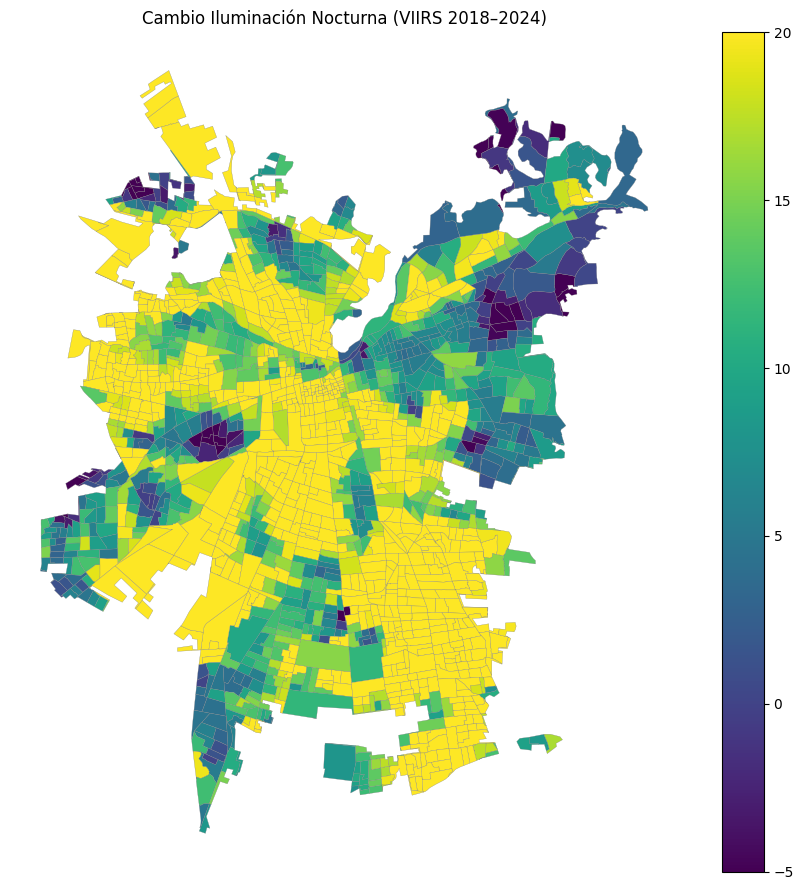

In [53]:
from shapely.geometry.base import BaseGeometry

zonas = zonas.set_geometry('geometry')

# Eliminar columnas de geometría extra (como centroide)
zonas = zonas[[col for col in zonas.columns if not isinstance(zonas[col].iloc[0], BaseGeometry) or col == zonas.geometry.name]]

# 2. Dividir en bloques y reducir en Earth Engine
bloques = [zonas.iloc[i:i+100] for i in range(0, len(zonas), 100)]
resultados = []

for bloque in tqdm(bloques, desc="Reduciendo zonas en EE"):
    bloque_ee = geemap.geopandas_to_ee(bloque)
    viirs_parcial = viirs_diff.reduceRegions(
        collection=bloque_ee,
        reducer=ee.Reducer.mean(),
        scale=500
    ).getInfo()
    resultados.extend(viirs_parcial['features'])

# 3. Asociar valores promedio a cada zona
viirs_mean_by_zona = {
    f['properties']['NZONA']: f['properties']['mean']
    for f in resultados if 'NZONA' in f['properties'] and 'mean' in f['properties']
}
zonas['viirs_diff_mean'] = zonas['NZONA'].map(viirs_mean_by_zona)

# 4. Visualización solo de Iluminación nocturna promedio
fig, ax = plt.subplots(figsize=(9, 9))

if zonas.crs.to_epsg() != 4326:
    zonas = zonas.to_crs(epsg=4326)

zonas.plot(
    column='viirs_diff_mean',
    cmap='viridis',
    legend=True,
    ax=ax,
    edgecolor='gray',
    linewidth=0.2,
    vmin=-5, vmax=20
)
ax.set_title('Cambio Iluminación Nocturna (VIIRS 2018–2024)')
ax.axis('off')

plt.tight_layout()
plt.show()


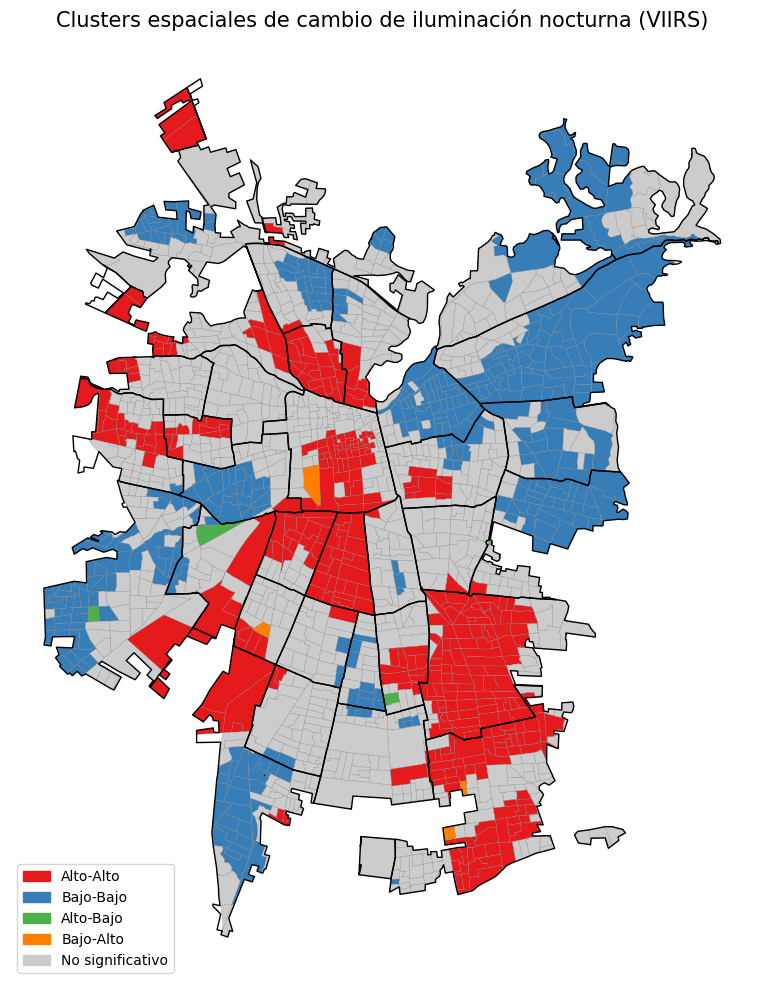

In [49]:
from esda.moran import Moran_Local
from libpysal.weights import Queen

# Usar solo zonas válidas (sin NaN en viirs_diff_mean)
zonas_validas = zonas.dropna(subset=['viirs_diff_mean'])

# Matriz de pesos espaciales
w = Queen.from_dataframe(zonas_validas)
moran_local_viirs = Moran_Local(zonas_validas['viirs_diff_mean'], w)

# Agregar resultados al GeoDataFrame
zonas_validas['viirs_cluster'] = 'No significativo'
zonas_validas.loc[(moran_local_viirs.q == 1) & (moran_local_viirs.p_sim < 0.05), 'viirs_cluster'] = 'Alto-Alto'
zonas_validas.loc[(moran_local_viirs.q == 2) & (moran_local_viirs.p_sim < 0.05), 'viirs_cluster'] = 'Bajo-Alto'
zonas_validas.loc[(moran_local_viirs.q == 3) & (moran_local_viirs.p_sim < 0.05), 'viirs_cluster'] = 'Bajo-Bajo'
zonas_validas.loc[(moran_local_viirs.q == 4) & (moran_local_viirs.p_sim < 0.05), 'viirs_cluster'] = 'Alto-Bajo'

# Visualización
import matplotlib.patches as mpatches
cluster_palette = {
    'Alto-Alto': '#e41a1c',
    'Bajo-Bajo': '#377eb8',
    'Alto-Bajo': '#4daf4a',
    'Bajo-Alto': '#ff7f00',
    'No significativo': '#cccccc'
}

fig, ax = plt.subplots(figsize=(10, 10))
zonas_validas.plot(ax=ax, color=zonas_validas['viirs_cluster'].map(cluster_palette), edgecolor='gray', linewidth=0.2)
Limite_Comunal.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Clusters espaciales de cambio de iluminación nocturna (VIIRS)", fontsize=15)
ax.axis('off')
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in cluster_palette.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10)
plt.tight_layout()
plt.show()

## Impacto L3 y L6

In [40]:
icvu_2016 = pd.read_csv("Datos/ICVU/ICVU_2016.csv")
icvu_2017 = pd.read_csv("Datos/ICVU/ICVU_2017.csv")
icvu_2020 = pd.read_csv("Datos/ICVU/ICVU_2020.csv")
icvu_2021 = pd.read_csv("Datos/ICVU/ICVU_2021.csv")
icvu_2022 = pd.read_csv("Datos/ICVU/ICVU_2022.csv")
icvu_2023 = pd.read_csv("Datos/ICVU/ICVU_2023.csv")

# Filtrar RM
df_icvus = {
    2016: icvu_2016[icvu_2016["REGION"] == 13],
    2017: icvu_2017[icvu_2017["region"] == "RM"],
    2020: icvu_2020[icvu_2020["NOM_REGION"] == "REGIÓN METROPOLITANA DE SANTIAGO"],
    2021: icvu_2021[icvu_2021["NOM_REGION"] == "REGIÓN METROPOLITANA DE SANTIAGO"],
    2022: icvu_2022[icvu_2022["NOM_REGION"] == "REGIÓN METROPOLITANA DE SANTIAGO"],
    2023: icvu_2023[icvu_2023["NOM_REGION"] == "REGIÓN METROPOLITANA DE SANTIAGO"]
}

# Promedios manuales 2018 y 2019 desde informes PDF
promedios = [
    {"año": 2016, "CON_MOV": df_icvus[2016]["CON_MOV_1"].mean(), "ICVU": df_icvus[2016]["ICVU_2016"].mean()},
    {"año": 2017, "CON_MOV": df_icvus[2017]["conectivid"].mean(), "ICVU": df_icvus[2017]["icvu_2017"].mean()},
    {"año": 2020, "CON_MOV": df_icvus[2020]["CON_MOV"].mean(), "ICVU": df_icvus[2020]["ICVU_2020"].mean()},
    {"año": 2021, "CON_MOV": df_icvus[2021]["CON_MOV"].mean(), "ICVU": df_icvus[2021]["ICVU_2021"].mean()},
    {"año": 2022, "CON_MOV": df_icvus[2022]["CON_MOV"].mean(), "ICVU": df_icvus[2022]["ICVU_2022"].mean()},
    {"año": 2023, "CON_MOV": df_icvus[2023]["CON_MOV"].mean(), "ICVU": df_icvus[2023]["ICVU_2023"].mean()}
]

comunas_metro_2016_2023 = [
    "Cerrillos", "Pedro Aguirre Cerda", "San Miguel", "San Joaquín", "Ñuñoa", "Providencia",
    "Quilicura", "Conchalí", "Independencia", "Santiago", "Macul", "La Reina"
]

comunas_upper = [c.upper() for c in comunas_metro_2016_2023]
for p in promedios:
    print(f"{p['año']} - Promedio CON_MOV: {p['CON_MOV']:.2f}, Promedio ICVU: {p['ICVU']:.2f}")


2016 - Promedio CON_MOV: 39.18, Promedio ICVU: 41.51
2017 - Promedio CON_MOV: 34.14, Promedio ICVU: 39.81
2020 - Promedio CON_MOV: 52.52, Promedio ICVU: 47.54
2021 - Promedio CON_MOV: 66.14, Promedio ICVU: 51.31
2022 - Promedio CON_MOV: 65.35, Promedio ICVU: 51.56
2023 - Promedio CON_MOV: 66.05, Promedio ICVU: 52.15


In [41]:
icvu_2016_ren = icvu_2016.rename(columns={
    "CON_LAB_1": "CON_LAB",
    "AMB_NEG_1": "AMB_NEG",
    "CON_SOC_1": "CON_SOC",
    "CON_MOV_1": "CON_MOV",
    "SAL_MED": "SAL_AMB",
    "VIV_ENT": "VIV_EN",
    "ICVU_2016": "ICVU"
})
icvu_2023_ren = icvu_2023.rename(columns={
    "ICVU_2023": "ICVU"
})

indicadores = ['CON_LAB', 'AMB_NEG', 'CON_SOC', 'CON_MOV', 'SAL_AMB', 'VIV_EN', 'ICVU']

icvu_comp = pd.merge(
    icvu_2016_ren[["COD_COMUNA", "NOM_COMUNA"] + indicadores],
    icvu_2023_ren[["COD_COMUNA"] + indicadores],
    on="COD_COMUNA",
    suffixes=('_2016', '_2023')
)

for col in indicadores:
    icvu_comp[f'delta_{col}'] = icvu_comp[f'{col}_2023'] - icvu_comp[f'{col}_2016']

# Verifica que comunas_upper esté en mayúsculas si es necesario
# Ejemplo: comunas_upper = ['PUENTE ALTO', 'MAIPÚ', ...]
promedios_general = icvu_comp[[f'delta_{col}' for col in indicadores]].mean()
promedios_metro = icvu_comp[icvu_comp['NOM_COMUNA'].isin(comunas_upper)][[f'delta_{col}' for col in indicadores]].mean()



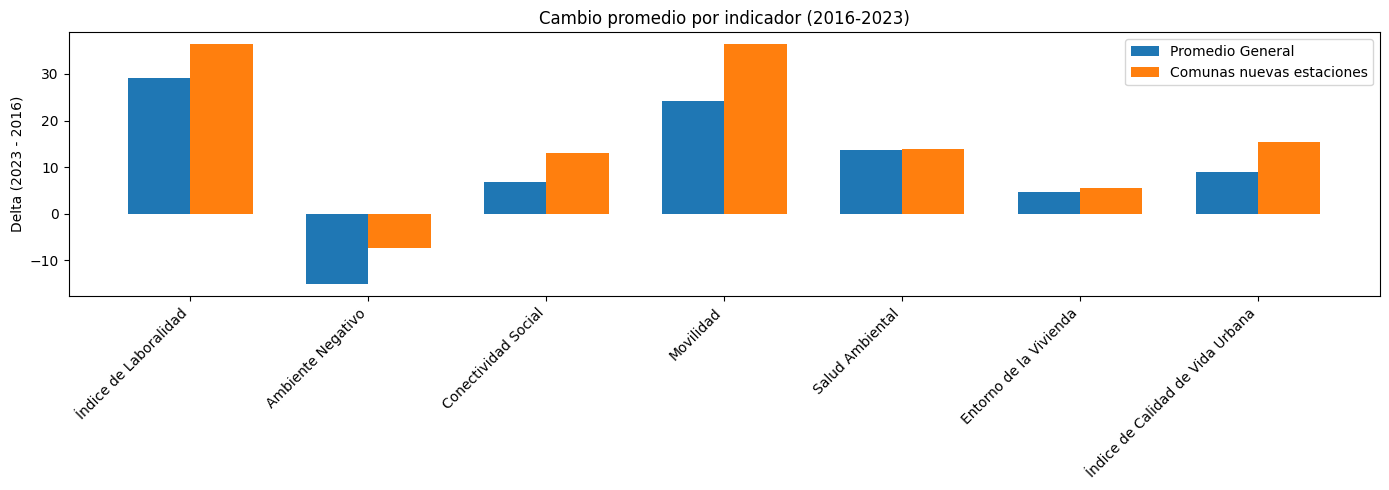

In [47]:
nombres_completos = {
    "CON_LAB": "Índice de Laboralidad",
    "AMB_NEG": "Ambiente Negativo",
    "CON_SOC": "Conectividad Social",
    "CON_MOV": "Movilidad",
    "SAL_AMB": "Salud Ambiental",
    "VIV_EN": "Entorno de la Vivienda",
    "ICVU": "Índice de Calidad de Vida Urbana"
}
x = np.arange(len(indicadores))
width = 0.35

# Usar nombres completos para las etiquetas
etiquetas = [nombres_completos[ind] for ind in indicadores]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, promedios_general, width, label='Promedio General')
ax.bar(x + width/2, promedios_metro, width, label='Comunas nuevas estaciones')

ax.set_ylabel('Delta (2023 - 2016)')
ax.set_title('Cambio promedio por indicador (2016-2023)')
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


In [43]:
# Crear columnas de diferencia porcentual por indicador
for col in indicadores:
    col_2016 = f"{col}_2016"
    col_2023 = f"{col}_2023"
    pct_col = f"pct_delta_{col}"

    # Evita división por cero
    icvu_comp[pct_col] = 100 * (icvu_comp[col_2023] - icvu_comp[col_2016]) / icvu_comp[col_2016].replace(0, np.nan)


# Columnas de % de cambio
pct_cols = [f"pct_delta_{col}" for col in indicadores]

# Promedio general de % de cambio
pct_promedios_general = icvu_comp[pct_cols].mean()

# Promedio solo para comunas con nuevas estaciones
pct_promedios_metro = icvu_comp[icvu_comp['NOM_COMUNA'].isin(comunas_upper)][pct_cols].mean()

print("Cambio porcentual promedio general entre 2016 y 2023:")
print(pct_promedios_general.round(2))

print("\nCambio porcentual promedio en comunas con nuevas estaciones:")
print(pct_promedios_metro.round(2))


Cambio porcentual promedio general entre 2016 y 2023:
pct_delta_CON_LAB     89.10
pct_delta_AMB_NEG      8.16
pct_delta_CON_SOC     36.29
pct_delta_CON_MOV    117.71
pct_delta_SAL_AMB     33.29
pct_delta_VIV_EN      31.89
pct_delta_ICVU        27.26
dtype: float64

Cambio porcentual promedio en comunas con nuevas estaciones:
pct_delta_CON_LAB    101.29
pct_delta_AMB_NEG    -17.37
pct_delta_CON_SOC     40.45
pct_delta_CON_MOV    136.13
pct_delta_SAL_AMB     29.70
pct_delta_VIV_EN      48.80
pct_delta_ICVU        40.93
dtype: float64


In [44]:
columnas_por_año = {
    2016: {
        "comuna": "NOM_COMUNA",
        "CON_LAB": "CON_LAB_1",
        "AMB_NEG": "AMB_NEG_1",
        "CON_SOC": "CON_SOC_1",
        "CON_MOV": "CON_MOV_1",
        "SAL_AMB": "SAL_MED",       # diferente nombre
        "VIV_EN": "VIV_ENT",        # diferente nombre
        "ICVU": "ICVU_2016"
    },
    2017: {
        "comuna": "nom_com",
        "CON_LAB": "condicione",
        "AMB_NEG": "ambiente_n",
        "CON_SOC": "condic_soc",
        "CON_MOV": "conectivid",
        "SAL_AMB": "salud_medi",
        "VIV_EN": "viv_entorn",
        "ICVU": "icvu_2017"
    },
    2020: {
        "comuna": "NOM_COMUNA",
        "CON_LAB": "CON_LAB",
        "AMB_NEG": "AMB_NEG",
        "CON_SOC": "CON_SOC",
        "CON_MOV": "CON_MOV",
        "SAL_AMB": "SAL_AMB",
        "VIV_EN": "VIV_EN",
        "ICVU": "ICVU_2020"
    },
    2021: {
        "comuna": "NOM_COMUNA",
        "CON_LAB": "CON_LAB",
        "AMB_NEG": "AMB_NEG",
        "CON_SOC": "CON_SOC",
        "CON_MOV": "CON_MOV",
        "SAL_AMB": "SAL_AMB",
        "VIV_EN": "VIV_EN",
        "ICVU": "ICVU_2021"
    },
    2022: {
        "comuna": "NOM_COMUNA",
        "CON_LAB": "CON_LAB",
        "AMB_NEG": "AMB_NEG",
        "CON_SOC": "CON_SOC",
        "CON_MOV": "CON_MOV",
        "SAL_AMB": "SAL_AMB",
        "VIV_EN": "VIV_EN",
        "ICVU": "ICVU_2022"
    },
    2023: {
        "comuna": "NOM_COMUNA",
        "CON_LAB": "CON_LAB",
        "AMB_NEG": "AMB_NEG",
        "CON_SOC": "CON_SOC",
        "CON_MOV": "CON_MOV",
        "SAL_AMB": "SAL_AMB",
        "VIV_EN": "VIV_EN",
        "ICVU": "ICVU_2023"
    }
}

In [45]:
promedios_comparados = []

for año, df in df_icvus.items():
    if año not in columnas_por_año:
        continue  # saltar si no está mapeado

    cols = columnas_por_año[año]
    col_comuna = cols["comuna"]

    # Asegurar mayúsculas
    df[col_comuna] = df[col_comuna].str.upper()

    df_metro = df[df[col_comuna].isin(comunas_upper)]
    df_otros = df[~df[col_comuna].isin(comunas_upper)]

    promedio = {"año": año}

    for ind in indicadores:
        col_ind = cols.get(ind)
        if col_ind not in df.columns:
            continue  # si la columna no existe en este año, saltar

        promedio[f"{ind}_metro"] = df_metro[col_ind].mean()
        promedio[f"{ind}_otros"] = df_otros[col_ind].mean()

    promedios_comparados.append(promedio)

# Convertir a DataFrame
df_comparacion = pd.DataFrame(promedios_comparados).sort_values("año")


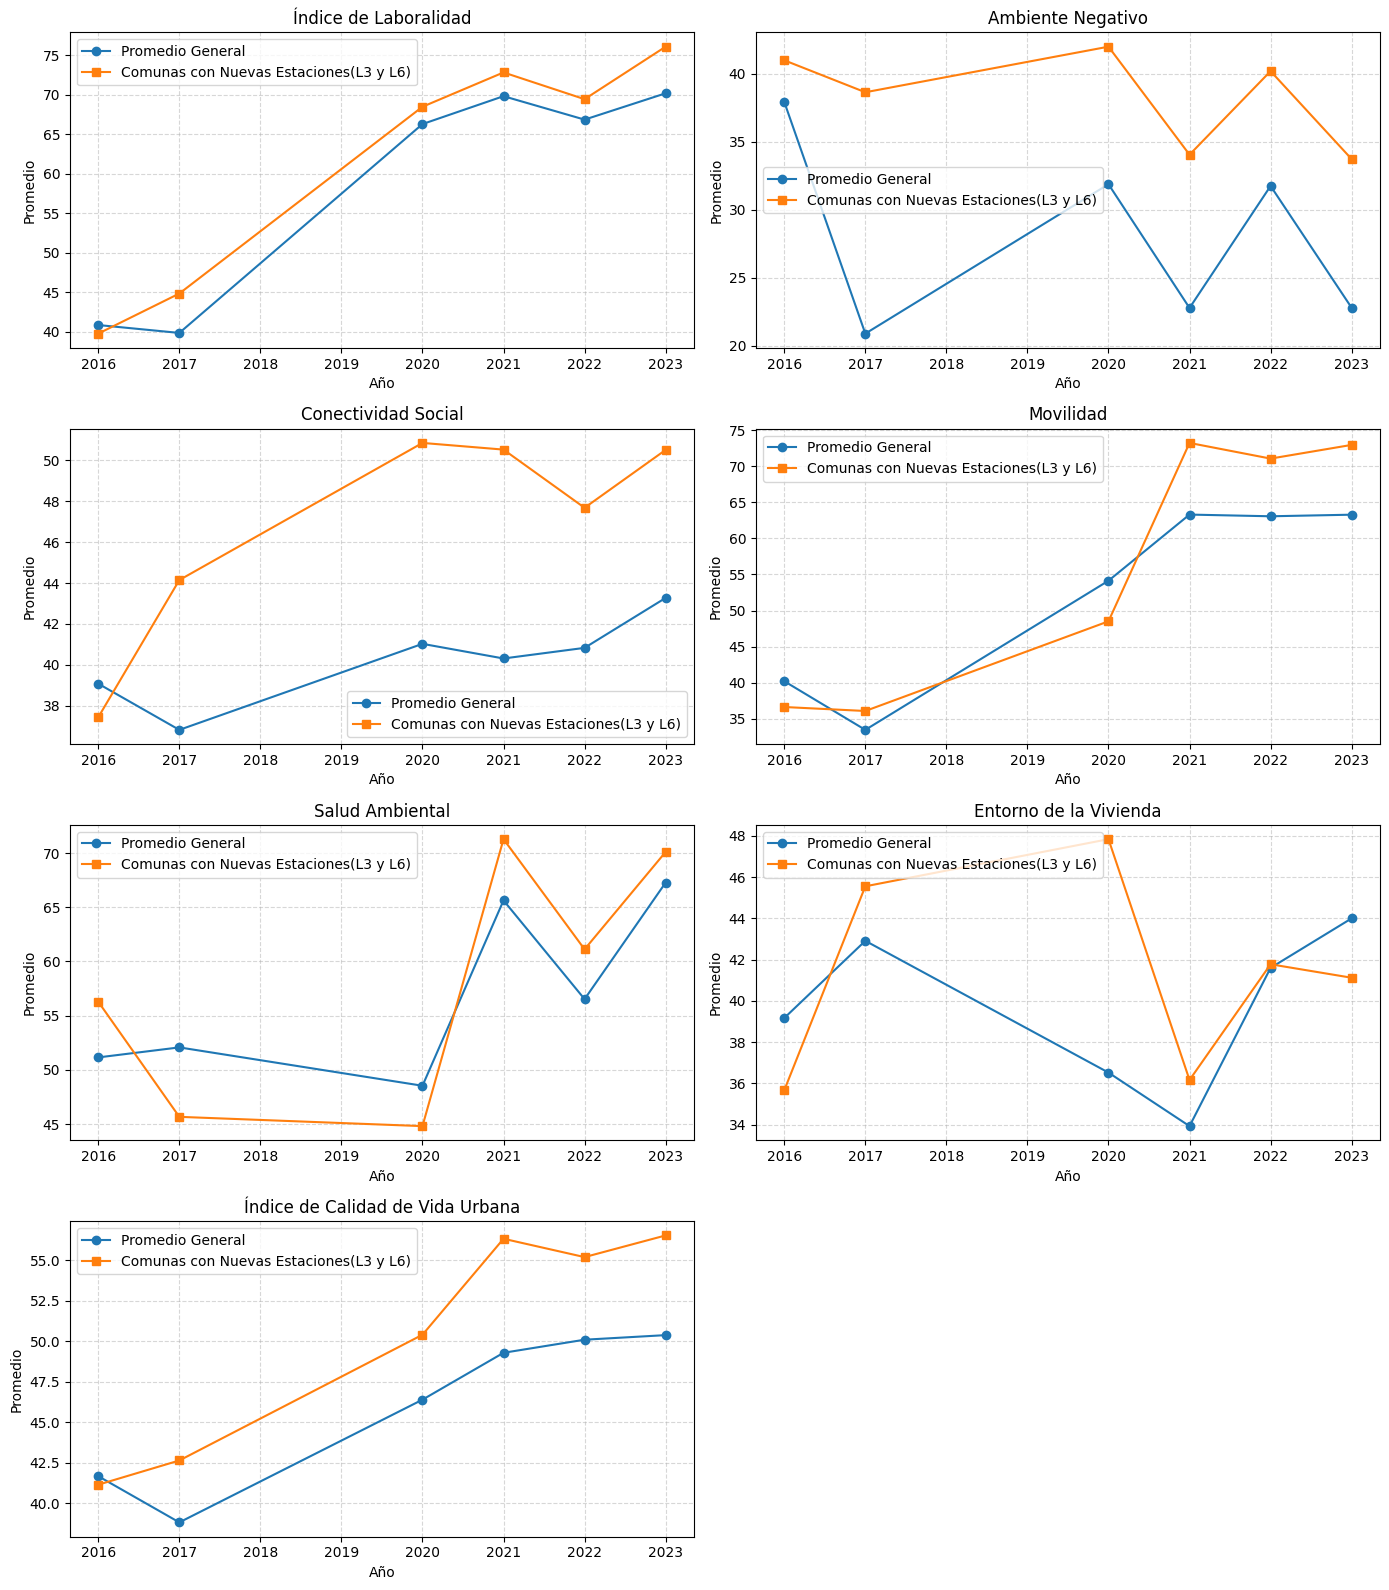

In [46]:
# Diccionario con nombres completos para cada indicador
nombres_completos = {
    "CON_LAB": "Índice de Laboralidad",
    "AMB_NEG": "Ambiente Negativo",
    "CON_SOC": "Conectividad Social",
    "CON_MOV": "Movilidad",
    "SAL_AMB": "Salud Ambiental",
    "VIV_EN": "Entorno de la Vivienda",
    "ICVU": "Índice de Calidad de Vida Urbana"
}

# Extraer los años y preparar los datos para graficar
años = df_comparacion['año'].tolist()

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, ind in enumerate(indicadores):
    ax = axes[i]
    # Para cada indicador, buscar las columnas correctas en df_comparacion
    col_metro = f"{ind}_metro"
    col_otros = f"{ind}_otros"
    if col_otros in df_comparacion.columns and col_metro in df_comparacion.columns:
        ax.plot(años, df_comparacion[col_otros], marker='o', label='Promedio General')
        ax.plot(años, df_comparacion[col_metro], marker='s', label='Comunas con Nuevas Estaciones(L3 y L6)')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
    ax.set_title(f'{nombres_completos.get(ind, ind)}')
    ax.set_xlabel('Año')
    ax.set_ylabel('Promedio')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

# Ocultar ejes vacíos si hay menos indicadores
for j in range(len(indicadores), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
